### **Plotting the Images**

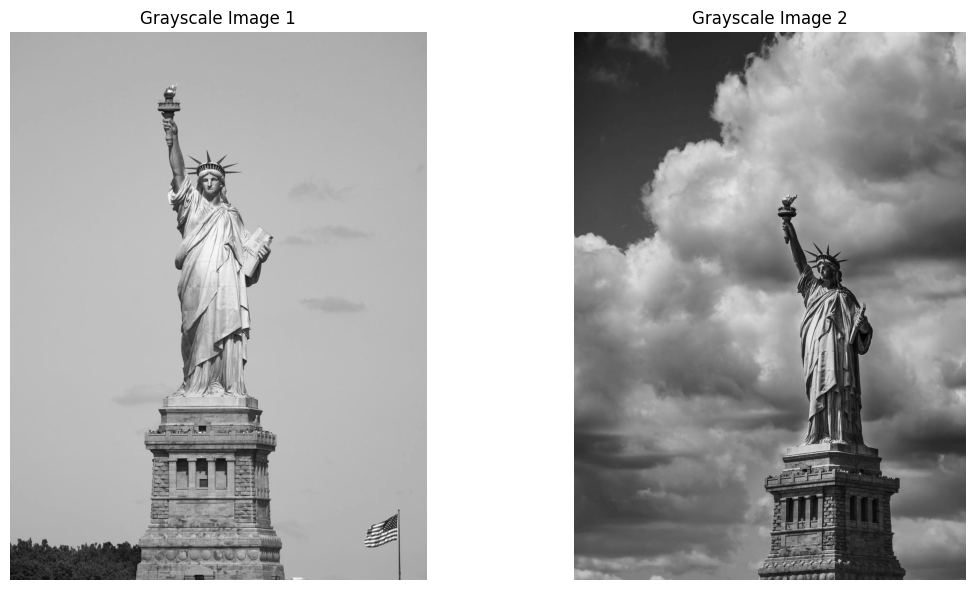

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

# Read the first image and convert to grayscale
img1 = Image.open("liberty1.jpg")
gray_img1 = img1.convert('L')  # 'L' mode means grayscale
img_array1 = np.array(gray_img1)

# Read the second image and convert to grayscale
img2 = Image.open("liberty2.jpg")  # Replace with your second image path
gray_img2 = img2.convert('L')
img_array2 = np.array(gray_img2)

# Plot the two grayscale images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Create a subplot with 1 row and 2 columns

# Display the first image
axes[0].imshow(img_array1, cmap='gray')
axes[0].set_title('Grayscale Image 1')
axes[0].axis('off')  # Hide axis

# Display the second image
axes[1].imshow(img_array2, cmap='gray')
axes[1].set_title('Grayscale Image 2')
axes[1].axis('off')  # Hide axis

plt.tight_layout()  # Adjust layout to avoid overlap
plt.show()


### **SIFT Class**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, convolve
from scipy.spatial.distance import cdist

class SIFT:
    def __init__(self, num_octaves=4, scales_per_octave=5, sigma=1.6, contrast_threshold=0.04):
        self.num_octaves = num_octaves
        self.scales_per_octave = scales_per_octave
        self.sigma = sigma
        self.contrast_threshold = contrast_threshold
        self.k = 2 ** (1 / scales_per_octave)
        
    def preprocess_image(self, image):
        """Convert image to grayscale and float format"""
        if len(image.shape) == 3:
            # Convert to grayscale if needed
            image = np.mean(image, axis=2)
        return image.astype(np.float32)
    
    def build_gaussian_pyramid(self, image):
        """Build the Gaussian pyramid for the image"""
        pyramid = []
        
        # For each octave
        for octave in range(self.num_octaves):
            octave_images = []
            
            # Downsample the base image for this octave
            if octave == 0:
                base_image = image
            else:
                base_image = pyramid[-1][self.scales_per_octave-3][::2, ::2]
            
            # Generate scale space for this octave
            for scale in range(self.scales_per_octave + 2):
                sigma_scale = self.sigma * (self.k ** scale)
                if octave == 0 and scale == 0:
                    # First image in first octave
                    blurred = gaussian_filter(base_image, sigma=sigma_scale)
                else:
                    # Additional sigma needed for next scale
                    sigma_diff = np.sqrt((self.k ** 2 - 1) * (sigma_scale / self.k) ** 2)
                    blurred = gaussian_filter(base_image if scale == 0 else octave_images[-1], 
                                              sigma=sigma_diff)
                octave_images.append(blurred)
            
            pyramid.append(octave_images)
        
        return pyramid
    
    def build_dog_pyramid(self, gaussian_pyramid):
        """Build the Difference of Gaussian pyramid"""
        dog_pyramid = []
        
        for octave_images in gaussian_pyramid:
            dog_octave = []
            for i in range(1, len(octave_images)):
                # Compute difference between adjacent Gaussian images
                dog = octave_images[i] - octave_images[i-1]
                dog_octave.append(dog)
            dog_pyramid.append(dog_octave)
        
        return dog_pyramid
    
    def find_keypoints(self, dog_pyramid):
        """Find keypoints in the DoG pyramid"""
        keypoints = []
        
        for octave_idx, dog_octave in enumerate(dog_pyramid):
            for scale_idx in range(1, len(dog_octave) - 1):
                # Current scale and adjacent scales
                prev_dog = dog_octave[scale_idx - 1]
                curr_dog = dog_octave[scale_idx]
                next_dog = dog_octave[scale_idx + 1]
                
                # Find local extrema
                for i in range(1, curr_dog.shape[0] - 1):
                    for j in range(1, curr_dog.shape[1] - 1):
                        # Get 3x3x3 cube around current pixel
                        cube = np.stack([
                            prev_dog[i-1:i+2, j-1:j+2],
                            curr_dog[i-1:i+2, j-1:j+2],
                            next_dog[i-1:i+2, j-1:j+2]
                        ])
                        
                        center_val = curr_dog[i, j]
                        
                        # Check if center is maximum or minimum
                        if (center_val > self.contrast_threshold and 
                            center_val == np.max(cube)) or \
                           (center_val < -self.contrast_threshold and 
                            center_val == np.min(cube)):
                            
                            # Calculate actual coordinates in original image
                            x = j * (2 ** octave_idx)
                            y = i * (2 ** octave_idx)
                            keypoints.append((x, y, octave_idx, scale_idx))
        
        return keypoints
    
    def compute_orientation(self, gaussian_pyramid, keypoints):
        """Compute orientation for each keypoint"""
        oriented_keypoints = []
        
        for x, y, octave_idx, scale_idx in keypoints:
            # Get the correct Gaussian image for this keypoint
            gaussian_image = gaussian_pyramid[octave_idx][scale_idx]
            
            # Convert back to coordinates in the current octave
            octave_x = int(x / (2 ** octave_idx))
            octave_y = int(y / (2 ** octave_idx))
            
            # Skip keypoints near borders
            if (octave_x < 8 or octave_x >= gaussian_image.shape[1] - 8 or
                octave_y < 8 or octave_y >= gaussian_image.shape[0] - 8):
                continue
            
            # Calculate gradient magnitude and orientation
            dx = gaussian_image[octave_y, octave_x+1] - gaussian_image[octave_y, octave_x-1]
            dy = gaussian_image[octave_y+1, octave_x] - gaussian_image[octave_y-1, octave_x]
            
            magnitude = np.sqrt(dx**2 + dy**2)
            orientation = np.rad2deg(np.arctan2(dy, dx)) % 360
            
            oriented_keypoints.append((x, y, octave_idx, scale_idx, orientation, magnitude))
        
        return oriented_keypoints
    
    def compute_descriptors(self, gaussian_pyramid, oriented_keypoints):
        """Compute SIFT descriptors for each keypoint"""
        descriptors = []
        
        for x, y, octave_idx, scale_idx, orientation, _ in oriented_keypoints:
            # Get the correct Gaussian image for this keypoint
            gaussian_image = gaussian_pyramid[octave_idx][scale_idx]
            
            # Convert back to coordinates in the current octave
            octave_x = int(x / (2 ** octave_idx))
            octave_y = int(y / (2 ** octave_idx))
            
            # Skip keypoints near borders
            if (octave_x < 8 or octave_x >= gaussian_image.shape[1] - 8 or
                octave_y < 8 or octave_y >= gaussian_image.shape[0] - 8):
                continue
            
            # Rotate to keypoint orientation
            cos_angle = np.cos(np.deg2rad(orientation))
            sin_angle = np.sin(np.deg2rad(orientation))
            
            # Simple 4x4 descriptor with 8 orientation bins (128 dimensions)
            hist = np.zeros((4, 4, 8), dtype=np.float32)
            
            # 16x16 window around keypoint
            for di in range(-8, 8):
                for dj in range(-8, 8):
                    # Rotate coordinates
                    rot_j = int(round(di * cos_angle - dj * sin_angle))
                    rot_i = int(round(di * sin_angle + dj * cos_angle))
                    
                    if (octave_y + rot_i < 0 or octave_y + rot_i >= gaussian_image.shape[0] - 1 or
                        octave_x + rot_j < 0 or octave_x + rot_j >= gaussian_image.shape[1] - 1):
                        continue
                    
                    # Calculate gradient
                    dx = gaussian_image[octave_y + rot_i, octave_x + rot_j + 1] - \
                         gaussian_image[octave_y + rot_i, octave_x + rot_j - 1]
                    dy = gaussian_image[octave_y + rot_i + 1, octave_x + rot_j] - \
                         gaussian_image[octave_y + rot_i - 1, octave_x + rot_j]
                    
                    magnitude = np.sqrt(dx**2 + dy**2)
                    orientation_bin = int(np.round(np.rad2deg(np.arctan2(dy, dx)) % 360) / 45) % 8
                    
                    # Determine which bin it belongs to
                    hist_i = (rot_i + 8) // 4
                    hist_j = (rot_j + 8) // 4
                    
                    if 0 <= hist_i < 4 and 0 <= hist_j < 4:
                        # Weight by distance from center (Gaussian weighting)
                        weight = np.exp(-(rot_i**2 + rot_j**2) / 32)
                        hist[hist_i, hist_j, orientation_bin] += magnitude * weight
            
            # Flatten the histogram
            descriptor = hist.flatten()
            
            # Normalize the descriptor
            norm = np.linalg.norm(descriptor)
            if norm > 0:
                descriptor /= norm
                
                # Clip values to 0.2 and renormalize
                descriptor = np.minimum(descriptor, 0.2)
                norm = np.linalg.norm(descriptor)
                if norm > 0:
                    descriptor /= norm
            
            descriptors.append((x, y, descriptor))
        
        return descriptors
    
    def extract_features(self, image):
        """Extract SIFT features from an image"""
        # Preprocess the image
        image = self.preprocess_image(image)
        
        # Build the Gaussian pyramid
        gaussian_pyramid = self.build_gaussian_pyramid(image)
        
        # Build the DoG pyramid
        dog_pyramid = self.build_dog_pyramid(gaussian_pyramid)
        
        # Find keypoints
        keypoints = self.find_keypoints(dog_pyramid)
        
        # Compute orientations
        oriented_keypoints = self.compute_orientation(gaussian_pyramid, keypoints)
        
        # Compute descriptors
        descriptors = self.compute_descriptors(gaussian_pyramid, oriented_keypoints)
        
        return descriptors
    
    def match_features(self, desc1, desc2, ratio_threshold=0.7):
        """Match features between two images using ratio test"""
        matches = []
        
        # Extract only the descriptor vectors
        desc_vectors1 = np.array([d[2] for d in desc1])
        desc_vectors2 = np.array([d[2] for d in desc2])
        
        if len(desc_vectors1) == 0 or len(desc_vectors2) == 0:
            return matches
        
        # Compute distances between all descriptors
        distances = cdist(desc_vectors1, desc_vectors2)
        
        # For each descriptor in first image
        for i in range(distances.shape[0]):
            # Find the two closest matches
            sorted_indices = np.argsort(distances[i])
            
            if len(sorted_indices) >= 2:
                closest_dist = distances[i, sorted_indices[0]]
                second_closest_dist = distances[i, sorted_indices[1]]
                
                # Apply ratio test (Lowe's ratio test)
                if closest_dist < ratio_threshold * second_closest_dist:
                    matches.append((i, sorted_indices[0]))
        
        return matches
    
    def calculate_similarity(self, image1, image2):
        """Calculate similarity between two images based on SIFT features"""
        # Extract features
        desc1 = self.extract_features(image1)
        desc2 = self.extract_features(image2)
        
        # Match features
        matches = self.match_features(desc1, desc2)
        
        # Calculate similarity score
        similarity = len(matches) / max(len(desc1), len(desc2), 1)
        
        return similarity, matches, desc1, desc2
    
    def visualize_matches(self, image1, image2, desc1, desc2, matches):
        """Visualize matching keypoints between two images"""
        # Create a new figure
        plt.figure(figsize=(10, 6))
        
        # Prepare a side-by-side image
        h1, w1 = image1.shape[:2]
        h2, w2 = image2.shape[:2]
        
        # Create a composite image
        if len(image1.shape) == 2:
            image1 = np.stack([image1] * 3, axis=-1)
        if len(image2.shape) == 2:
            image2 = np.stack([image2] * 3, axis=-1)
            
        composite = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
        composite[:h1, :w1] = image1
        composite[:h2, w1:w1+w2] = image2
        
        plt.imshow(composite)
        
        # Draw lines between matching keypoints
        for i, j in matches:
            x1, y1 = desc1[i][0], desc1[i][1]
            x2, y2 = desc2[j][0], desc2[j][1]
            x2 += w1  # Adjust x-coordinate for the second image
            
            plt.plot([x1, x2], [y1, y2], 'r-')
            
        plt.title(f'SIFT matches: {len(matches)} keypoints')
        plt.axis('off')
        plt.tight_layout()
        
        # Display the plot
        plt.show()


### **Comparing two Images using SIFT**

Similarity Score: 0.04439746300211417
Number of Matches: 210


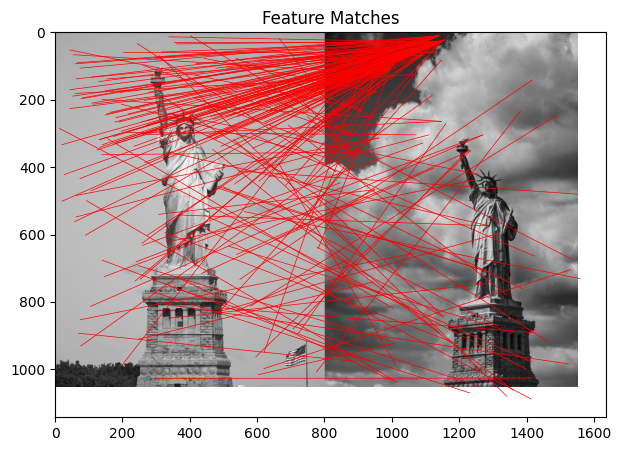

In [11]:
def compare_images(image1_path, image2_path):
    """Compare two images using SIFT features"""
    # Import here to avoid dependency issues if not needed
    from PIL import Image
    
    # Load images
    image1 = np.array(Image.open(image1_path))
    image2 = np.array(Image.open(image2_path))
    
    # Initialize SIFT
    sift = SIFT()
    
    # Calculate similarity
    similarity, matches, desc1, desc2 = sift.calculate_similarity(image1, image2)
    
    print(f"Similarity score: {similarity:.4f}")
    print(f"Number of matches: {len(matches)}")
    
    # Visualize matches
    sift.visualize_matches(image1, image2, desc1, desc2, matches)
    
    return similarity

# Continue the implementation
def main():
    # Read two images
    image1 = cv2.imread("liberty1.jpg", cv2.IMREAD_GRAYSCALE)
    image2 = cv2.imread("liberty2.jpg", cv2.IMREAD_GRAYSCALE)

    # Resize image2 to match the height of image1
    if image1.shape[0] != image2.shape[0]:
        new_width = int(image2.shape[1] * (image1.shape[0] / image2.shape[0]))
        image2_resized = cv2.resize(image2, (new_width, image1.shape[0]))
    else:
        image2_resized = image2

    # Combine images horizontally
    combined_image = np.hstack((image1, image2_resized))

    # Instantiate the SIFT detector
    sift = SIFT()

    # Calculate similarity
    similarity, matches, desc1, desc2 = sift.calculate_similarity(image1, image2)

    # Display results
    print(f"Similarity Score: {similarity}")
    print(f"Number of Matches: {len(matches)}")

    # Visualize matches
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    # Combine images horizontally
    ax.imshow(combined_image, cmap='gray')

    # Draw matches
    for match in matches:
        idx1, idx2 = match

        x1, y1, _ = desc1[idx1]
        x2, y2, _ = desc2[idx2]

        # Adjust x2 for second image offset in combined image
        x2 += image1.shape[1]

        # Draw lines between matched points
        ax.plot([x1, x2], [y1, y2], 'r-', linewidth=0.5)

    plt.title("Feature Matches")
    plt.show()

if __name__ == "__main__":
    main()

## **Module Overview and Functionality**

This Python code implements the Scale-Invariant Feature Transform (SIFT) algorithm, which is commonly used in computer vision tasks like image matching and object recognition. Below is a detailed explanation of the modules, functions, parameters, processes, and outputs in this implementation.

---

### **Class: `SIFT`**
Encapsulates all the operations required to extract and match SIFT features from images.

#### **Constructor: `__init__`**
Initializes the SIFT object with parameters:
- `num_octaves` (int): Number of octaves in the Gaussian pyramid.
- `scales_per_octave` (int): Number of scales in each octave.
- `sigma` (float): Initial Gaussian blur level.
- `contrast_threshold` (float): Threshold for filtering weak keypoints.
- `k` (float): Scale multiplier between levels.

---

### **Methods**

#### 1. `preprocess_image(image)`
Converts the input image to grayscale and ensures it is in `float32` format.
- **Input**: Image array (3D or 2D).
- **Output**: Grayscale, float-format image.

#### 2. `build_gaussian_pyramid(image)`
Creates a Gaussian pyramid by progressively blurring and downsampling the image.
- **Parameters**: `image` (2D array).
- **Output**: List of lists, where each inner list contains the Gaussian pyramid for an octave.

#### 3. `build_dog_pyramid(gaussian_pyramid)`
Generates the Difference of Gaussian (DoG) pyramid by subtracting adjacent Gaussian images.
- **Input**: Gaussian pyramid.
- **Output**: DoG pyramid, highlighting regions with significant intensity changes.

#### 4. `find_keypoints(dog_pyramid)`
Detects keypoints by identifying local extrema in the DoG pyramid.
- **Input**: DoG pyramid.
- **Output**: List of keypoints as `(x, y, octave_idx, scale_idx)` tuples.

#### 5. `compute_orientation(gaussian_pyramid, keypoints)`
Calculates the orientation and magnitude of gradients around each keypoint.
- **Input**: Gaussian pyramid, list of keypoints.
- **Output**: List of oriented keypoints `(x, y, octave_idx, scale_idx, orientation, magnitude)`.

#### 6. `compute_descriptors(gaussian_pyramid, oriented_keypoints)`
Generates 128-dimensional SIFT descriptors for each keypoint by analyzing gradient orientations.
- **Input**: Gaussian pyramid, oriented keypoints.
- **Output**: List of descriptors, each as `(x, y, descriptor)`.

#### 7. `extract_features(image)`
Extracts SIFT features from an image.
- **Process**:
  1. Preprocess the image.
  2. Build Gaussian and DoG pyramids.
  3. Find keypoints.
  4. Compute orientations and descriptors.
- **Input**: Image array.
- **Output**: List of SIFT descriptors.

#### 8. `match_features(desc1, desc2, ratio_threshold=0.7)`
Matches features between two images using Lowe's ratio test.
- **Inputs**:
  - `desc1`, `desc2`: SIFT descriptors from two images.
  - `ratio_threshold` (float): Threshold to filter ambiguous matches.
- **Output**: List of matches `(i, j)`.

#### 9. `calculate_similarity(image1, image2)`
Computes similarity between two images by extracting and matching SIFT features.
- **Input**: Two image arrays.
- **Output**: Matched features indicating similarity.

---

### **Key Parameters and Their Meaning**
- **Octaves and Scales**: Control the levels of the pyramid and the scale-space representation.
- **Sigma**: Determines the level of Gaussian smoothing.
- **Contrast Threshold**: Filters out weak keypoints.

---

### **Outputs**
1. **Keypoints**: Points of interest in the image, scale- and rotation-invariant.
2. **Descriptors**: Numerical vectors describing local patterns around keypoints.
3. **Matches**: Corresponding features between two images.